C:\Users\Chestnut\AppData\Local\Temp\ipykernel_17136\3710354871.py:69: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  ax.set_ylim(0, 10**2)


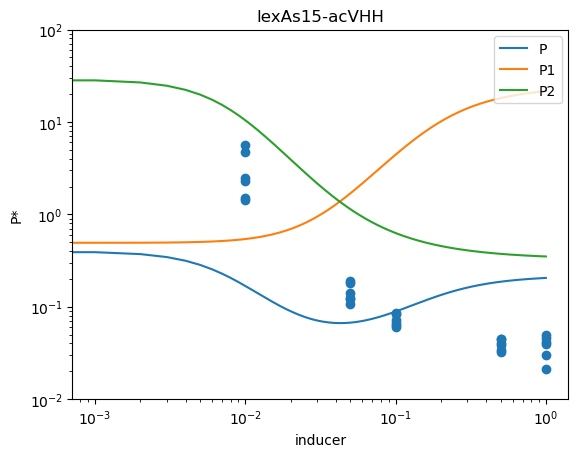

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd


df = pd.read_csv("E:\Desktop\hybir\\419_4.csv")
x = df["inducer2"]
y = df["RPU"]
L1=df["LBD1"]
L1= L1.values.flatten()[0]
L2=df["LBD2"]
L2= L2.values.flatten()[0]

# 设置x和y的坐标范围
I1= np.arange(0,100,0.1)
I2= np.arange(0,1,0.001)
#kd= np.arange(10,100000,1)
#I= np.arange(0,10,0.01)


k11=0.000284363

k21=0.00611078

k31=0.899893641
kd1=0.745553315


k12=0.000170903

k22=0.145665169

k32=737.5150757
kd2=40.97704697


Imax= 35.84931505
I01=0.015930056

I02=0.035485714

x1 = np.sqrt((k21*I1+1)*(k21*I1+1)+ 8 * L1 * (k21*k21*k31*I1*I1 + k11))
x2 = np.sqrt((k22*I2+1)*(k22*I2+1)+ 8 * L2 * (k22*k22*k32*I2*I2 + k12))
F1 = np.log(L1 / 2) + np.log((x1 - (k21 *  I1+ 1)) / (x1 + (k21 *  I1+ 1))) + np.log(kd1)
F2 = np.log(L2 / 2) + np.log((x2 - (k22 *  I2+ 1)) / (x2 + (k22 *  I2+ 1))) + np.log(kd2)
P =  Imax*(1 / (1 + np.exp(-F1)))*(1 /(1 + np.exp(F2))) + I01
P1= Imax*(1 / (1 + np.exp(-F1))) + I01
P2= Imax*(1/(1 + np.exp(F2)))+ I02

fig, ax = plt.subplots()


#z=df['326']
# 绘制曲线和散点图
ax.plot(I2, P,label='P')
ax.plot(I2, P1,label='P1')
ax.plot(I2, P2,label='P2')

#ax.plot(L, P2, label="P2")
ax.scatter(x, y)
#ax.scatter(x, z, label="326")

# 设置横纵坐标轴的取值范围和标签
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(0, 10**2)
ax.legend(loc="upper right")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("inducer")
ax.set_ylabel("P*")
'''
x1=0.001

y1=0.125481696	

plt.scatter(x1,y1)



x2=0.001

y2=0.126685934

plt.scatter(x2,y2)
'''
# 添加图例并显示图形
plt.title('lexAs15-acVHH')
ax.set_ylim(10**(-2),10**2)
#plt.savefig("E:\Desktop\sensor CV\lexAs15-acVHH.svg",format="svg")

plt.show()

C:\Users\Chestnut\AppData\Local\Temp\ipykernel_17136\1560183901.py:55: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  ax.set_ylim(0, 10 ** 2)


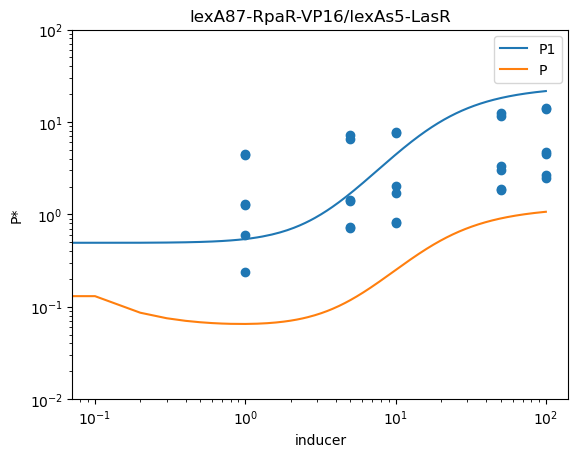

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d

df = pd.read_csv("E:\Desktop\hybir\\419_2.csv")
x = df["inducer2"]
y = df["RPU"]
L1 = df["LBD1"]
L2 = df["LBD2"]

I1 = np.arange(0, 100, 0.1)
I2 = np.arange(0, 100, 0.1)

k11 = 0.000284363
k21 = 0.00611078
k31 = 0.899893641
kd1 = 0.745553315

k12 = 0.000170903
k22 = 0.145665169
k32 = 737.5150757
kd2 = 40.97704697

Imax = 35.84931505
I01=0.015930056

I02=0.035485714

# 使用线性插值将 L1 和 L2 扩展到与 I1 和 I2 长度相同
interp_L1 = interp1d(np.arange(len(L1)), L1, kind='linear')
interp_L2 = interp1d(np.arange(len(L2)), L2, kind='linear')
L1_expanded = interp_L1(np.linspace(0, len(L1) - 1, len(I1)))
L2_expanded = interp_L2(np.linspace(0, len(L2) - 1, len(I2)))

x1 = np.sqrt((k21 * I1 + 1) * (k21 * I1 + 1) + 8 * L1_expanded * (k21 * k21 * k31 * I1 * I1 + k11))
x2 = np.sqrt((k22 * I2 + 1) * (k22 * I2 + 1) + 8 * L2_expanded * (k22 * k22 * k32 * I2 * I2 + k12))
F1 = np.log(L1_expanded / 2) + np.log((x1 - (k21 * I1 + 1)) / (x1 + (k21 * I1 + 1))) + np.log(kd1)
F2 = np.log(L2_expanded / 2) + np.log((x2 - (k22 * I2 + 1)) / (x2 + (k22 * I2 + 1))) + np.log(kd2)
P = Imax * (1 / (1 + np.exp(-F1))) *(1 / (1 + np.exp(F2))) + I02
P1=(Imax/(1+np.exp(-F1)))+I01
P2=(Imax/(1+np.exp(-F2)))+I02
P3=P2-P1
fig, ax = plt.subplots()

#ax.plot(I1, P)
ax.plot(I2, P1, label="P1")
#ax.plot(I2, P2, label="P2")
ax.plot(I2, P, label="P")

ax.scatter(x, y)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(0, 10 ** 2)
ax.set_xlabel("inducer")
ax.set_ylabel("P*")
ax.legend(loc="upper right")
plt.title('lexA87-RpaR-VP16/lexAs5-LasR')
ax.set_ylim(10 ** (-2), 10 ** 2)

plt.show()

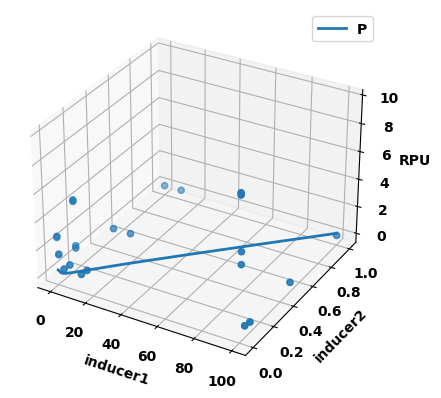

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

df = pd.read_csv("E:\Desktop\hybir\\419_4.csv")
x = df["inducer1"]
y = df["inducer2"]
z = df["RPU"]
L1 = df["LBD1"]
L1 = L1.values.flatten()[0]
L2 = df["LBD2"]
L2 = L2.values.flatten()[0]

# 设置x和y的坐标范围
I1 = np.arange(0, 100, 0.1)
I2 = np.arange(0, 1, 0.001)

k11 = 0.000284363
k21 = 0.00611078
k31 = 0.899893641
kd1 = 0.745553315

k12 = 0.000170903
k22 = 0.145665169
k32 = 737.5150757
kd2 = 40.97704697

Imax = 35.84931505
I01 = 0.015930056
I02 = 0.035485714

x1 = np.sqrt((k21 * I1 + 1) * (k21 * I1 + 1) + 8 * L1 * (k21 * k21 * k31 * I1 * I1 + k11))
x2 = np.sqrt((k22 * I2 + 1) * (k22 * I2 + 1) + 8 * L2 * (k22 * k22 * k32 * I2 * I2 + k12))
F1 = np.log(L1 / 2) + np.log((x1 - (k21 * I1 + 1)) / (x1 + (k21 * I1 + 1))) + np.log(kd1)
F2 = np.log(L2 / 2) + np.log((x2 - (k22 * I2 + 1)) / (x2 + (k22 * I2 + 1))) + np.log(kd2)
P = Imax * (1 / (1 + np.exp(-F1))) * (1 / (1 + np.exp(F2))) + I01
P1 = Imax * (1 / (1 + np.exp(-F1))) + I01
P2 = Imax * (1 / (1 + np.exp(F2))) + I02

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 绘制3D曲线，并调整线条粗细和立体感
ax.plot(I1, I2, P, label='P', linewidth=2, zdir='z')
#ax.plot(I1, I2, P1, label='P1', linewidth=2, zdir='z')
#ax.plot(I1, I2, P2, label='P2', linewidth=2, zdir='z')

# 绘制散点图，并放在对应的坐标上
ax.scatter(x, y ,z)

# 设置坐标轴标签
ax.set_xlabel('inducer1')
ax.set_ylabel('inducer2')
ax.set_zlabel('RPU')

# 设置图例
ax.legend()

plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap

def promoter(m1, m2):
    I1 = m1
    I2 = m2
    k11 = 0.000268715
    k21 = 0.007083518
    k31 = 0.760771692
    kd1 = 0.745553315
    k12 = 0.000171923
    k22 = 0.256016091
    k32 = 225.0817618
    kd2 = 40.97704697
    Imax1 = 35.84931505
    Imax2 = 0.85546578
    I01 = 0.015930056
    I02 = 0.035485714
    L1 = 6
    L2 = 6

    x1 = np.sqrt((k21 * I1 + 1) * (k21 * I1 + 1) + 8 * L1 * (k21 * k21 * k31 * I1 * I1 + k11))
    x2 = np.sqrt((k22 * I2 + 1) * (k22 * I2 + 1) + 8 * L2 * (k22 * k22 * k32 * I2 * I2 + k12))
    x3 = np.sqrt(( 1) * (1) + 8 * L1 * (k11))
    x4 =  np.sqrt((1) * (1) + 8 * L2 * (k12))
    F1 = np.log(L1 / 2) + np.log((x1 - (k21 * I1 + 1)) / (x1 + (k21 * I1 + 1))) + np.log(kd1)
    F2 = np.log(L2 / 2) + np.log((x2 - (k22 * I2 + 1)) / (x2 + (k22 * I2 + 1))) + np.log(kd2)
    F3 = np.log(L1 / 2) + np.log((x1 - ( 1)) / (x1 + (1))) + np.log(kd1)
    F4 = np.log(L2 / 2) + np.log((x2 - ( 1)) / (x2 + (1))) + np.log(kd2)
    P1 =  (Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F2))) + I01 #++
    P2 =  (Imax1 / (1 + np.exp(-F3))) * (Imax2 / (1 + np.exp(F4))) + I01 #--
    P3 =  (Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F4))) + I01 #+-
    P4 =  (Imax1 / (1 + np.exp(-F3))) * (Imax2 / (1 + np.exp(F2))) + I01 #-+
    fold = P3/P1+P3/P2+P3/P4
    strength = 3*P3-(P4+P1+P2)
   
    return P1,P2,P3,P4

M1 = np.arange(0, 100, 1)
M2 = np.arange(0,1, 0.01)

M1, M2 = np.meshgrid(M1, M2)
Y = np.array(list(map(lambda t : promoter(t[0], t[1]), zip(M1.flatten(), M2.flatten()))))
Y.shape = M1.shape

fig = plt.figure(facecolor='w')
ax = fig.add_subplot(projection='3d')
ax.plot_surface(M1,M2,Y,rstride=1,cstride=1,cmap='viridis')
#ax.set_ylim(0.1, 0)
'''
# 创建自定义的红蓝颜色映射
colors = [ (0.16, 0.47, 0.71),(0.78, 0.14, 0.14)]  # 红蓝颜色
n_bins = 1000  # 使用1000个颜色级别
cmap_name = 'blue_red'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

surf = ax.plot_surface(M1, M2, Y, rstride=1, cstride=1, cmap=cm)
'''
plt.title('activator7 & repressor6', fontweight='bold', fontsize=14, loc='center')

ax.set_xlabel('inducer1')
ax.set_ylabel('inducer2')
ax.set_zlabel('P')

df = pd.read_csv("E:\Desktop\hybir\\419_4.csv")
a = df["inducer1"]
b = df["inducer2"]
c = df["RPU"]
#ax.scatter(a,b,c, c=c, cmap=plt.cm.jet)

calculated_c = [promoter(a_val, b_val) for a_val, b_val in zip(a, b)]

# 计算散点高度与曲面高度的差异
difference = np.abs(np.array(c) - np.array(calculated_c))

# 检查差异是否足够小，以确定散点是否在曲面上
threshold = 0.1  # 可以根据需要调整阈值
on_surface_indices = np.where(difference < threshold)[0]

# 输出在曲面上的散点数目
print(f"Number of points on surface: {len(on_surface_indices)}")
#ax.set_zlim(10 ** (-2), 15)

# 计算R方
mean_rpu = np.mean(c)
mean_surface_p = np.mean(calculated_c)
tss = np.sum((c - mean_rpu) ** 2)
rss = np.sum((c - calculated_c) ** 2)
r_square = 1 - (rss / tss)

# 在图上显示R方值
plt.annotate('R² = {:.4f}'.format(r_square), xy=(0.15, 0.95), xycoords='axes fraction', fontsize=10,weight='bold')

plt.show()

NameError: name 'Imax' is not defined

NR&LBD

Number of points on surface: 0


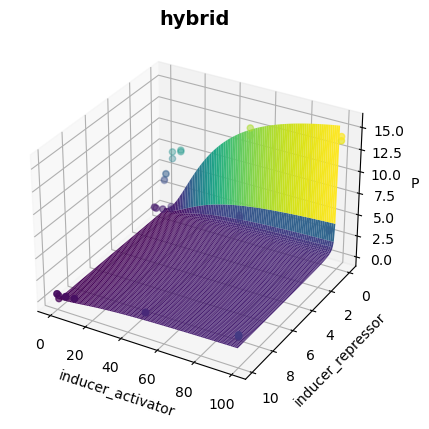

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd

def promoter(m1, m2):
    I1 = m1
    I2 = m2
    k11 = 0.000268715

    k21 = 0.007083518

    k31 = 0.760771692
    kx1 = 1.086833596
    kx2 = 4.230793476
    kd1 = 0.745553315


    k12 = 0.000171923
    k22 = 0.256016091
    k32 = 225.0817618
    kd2 = 40.97704697


    Imax1 = 35.84931505
    Imax2 = 0.85546578

    I01 = 0.006969286
    I02 = 0.011797972
    L1 = 6
    L2 = 0.8

    #x1 = np.sqrt((k21*I1+kx1+kx2*k21*I1+1)*(k21*I1+kx1+kx2*k21*I1+1)+ 8 * L1 * (k21*k21*k31*I1*I1 + k11+k11*kx1*kx1+k31*k21*k21*kx2*kx2*I1*I1))
    x1 = np.sqrt((k21*I1+1)*(k21*I1+1)+ 8 * L1 * (k21*k21*k31*I1*I1 +k11))
    x2 = np.sqrt((k22 * I2 + 1) * (k22 * I2 + 1) + 8 * L2 * (k22 * k22 * k32 * I2 * I2 + k12))
    #F1 = np.log(L1 / 2) + np.log((x1 - (k21*I1+kx1+kx2*k21*I1+1)) / (x1 + (k21*I1+kx1+kx2*k21*I1+1))) + np.log(kd1)
    F1 =   np.log(L1 / 2) + np.log((x1 - (k21 * I1 + 1)) / (x1 + (k21 * I1 + 1))) + np.log(kd1)
    F2 = np.log(L2 / 2) + np.log((x2 - (k22 * I2 + 1)) / (x2 + (k22 * I2 + 1))) + np.log(kd2)
    P =  (Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F2))) + I01
    a1=(1 / (1 + np.exp(-F1)))
    a2=(1 / (1 + np.exp(F2)))

    #print(a1,a2)

    return P

M1 = np.arange(0, 100, 1)
M2 = np.arange(0, 10, 0.1)
M1, M2 = np.meshgrid(M1, M2)
Y = np.array(list(map(lambda t : promoter(t[0], t[1]), zip(M1.flatten(), M2.flatten()))))
Y.shape = M1.shape

fig = plt.figure(facecolor='w')
ax = fig.add_subplot(projection='3d')

# 创建自定义的红蓝颜色映射
colors = [ (0.16, 0.47, 0.71),(0.78, 0.14, 0.14)]  # 红蓝颜色
n_bins = 1000  # 使用1000个颜色级别
cmap_name = 'blue_red'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

surf = ax.plot_surface(M1, M2, Y, rstride=1, cstride=1, cmap='viridis')
plt.title('hybrid', fontweight='bold', fontsize=14, loc='center')

ax.set_xlabel('inducer_activator')
ax.set_ylabel('inducer_repressor')
#ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_zlabel('P')
ax.set_ylim(ax.get_ylim()[::-1])

df = pd.read_csv("E:\Desktop\hybir\\419_2.csv")
a = df["inducer1"]
b = df["inducer2"]
c = df["RPU"]
ax.scatter(a,b,c, c=c, cmap='viridis')

calculated_c = [promoter(a_val, b_val) for a_val, b_val in zip(a, b)]

# 计算散点高度与曲面高度的差异
difference = np.abs(np.array(c) - np.array(calculated_c))

# 检查差异是否足够小，以确定散点是否在曲面上
threshold = 0.1  # 可以根据需要调整阈值
on_surface_indices = np.where(difference < threshold)[0]

# 输出在曲面上的散点数目
print(f"Number of points on surface: {len(on_surface_indices)}")
#ax.set_zlim(10 ** (-2), 15)

# 计算R方
mean_rpu = np.mean(c)
mean_surface_p = np.mean(calculated_c)
tss = np.sum((c - mean_rpu) ** 2)
rss = np.sum((c - calculated_c) ** 2)
r_square = 1 - (rss / tss)

# 在图上显示R方值
#plt.annotate('R² = {:.4f}'.format(r_square), xy=(0.15, 0.95), xycoords='axes fraction', fontsize=10,weight='bold')
plt.savefig("E:\Desktop\\hybrid.svg")
plt.show()

Number of points on surface: 19


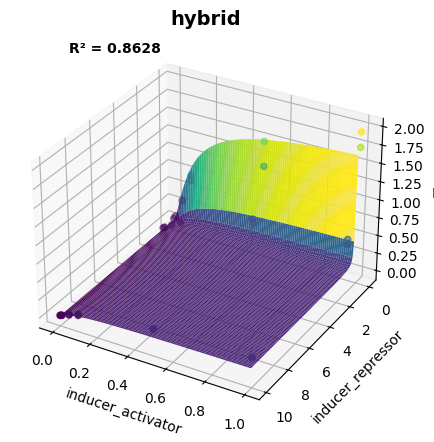

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd

def promoter(m1, m2):
    I1 = m1
    I2 = m2
    k11 = 4.67083E-05
    k21 = 5.31018734
    k31 = 0.650004327
    kx1 = 1.086833596
    kx2 = 4.230793476
    kd1 = 1.13083303
    k12 = 0.000171923
    k22 = 0.256016091
    k32 = 225.0817618
    kd2 = 40.97704697

    Imax1 = 35.84931505
    Imax2 = 0.85546578
    L1=0.46
    L2=0.8

    I01 = 0.006969286
    I02 = 0.011797972


    x1 = np.sqrt((k21*I1+kx1+kx2*k21*I1+1)*(k21*I1+kx1+kx2*k21*I1+1)+ 8 * L1 * (k21*k21*k31*I1*I1 + k11+k11*kx1*kx1+k31*k21*k21*kx2*kx2*I1*I1))
    x2 = np.sqrt((k22 * I2 + 1) * (k22 * I2 + 1) + 8 * L2 * (k22 * k22 * k32 * I2 * I2 + k12))
    F1 = np.log(L1 / 2) + np.log((x1 - (k21*I1+kx1+kx2*k21*I1+1)) / (x1 + (k21*I1+kx1+kx2*k21*I1+1))) + np.log(kd1)
    F2 = np.log(L2 / 2) + np.log((x2 - (k22 * I2 + 1)) / (x2 + (k22 * I2 + 1))) + np.log(kd2)
    x3 = np.sqrt((kx1+1)*(kx1+1)+ 8 * L1 * ( k11+k11*kx1*kx1))
    x4 = np.sqrt(( 1) * ( 1) + 8 * L2 * (k12))
    F3 = np.log(L1 / 2) + np.log((x3 - (kx1+1)) / (x3 + (kx1+1))) + np.log(kd1)
    F4 = np.log(L2 / 2) + np.log((x4 - (1)) / (x4 + ( 1))) + np.log(kd2)
    P1 =  (Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F2))) + I01 #++
    P2 =  (Imax1 / (1 + np.exp(-F3))) * (Imax2 / (1 + np.exp(F4))) + I01 #--
    P3 =  (Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F4))) + I01 #+-
    P4 =  (Imax1 / (1 + np.exp(-F3))) * (Imax2 / (1 + np.exp(F2))) + I01 #-+
    fold = P3/P1+P3/P2+P3/P4
    
    strength = 3*P3-(P4+P1+P2)
    a1=(1 / (1 + np.exp(-F1)))
    a2=(1 / (1 + np.exp(F2)))

    #print(a1,a2)

    return P1

M1 = np.arange(0, 1, 0.01)
M2 = np.arange(0, 10, 0.1)
M1, M2 = np.meshgrid(M1, M2)
Y = np.array(list(map(lambda t : promoter(t[0], t[1]), zip(M1.flatten(), M2.flatten()))))
Y.shape = M1.shape

fig = plt.figure(facecolor='w',figsize=(5.08,5.08))
ax = fig.add_subplot(projection='3d')

# 创建自定义的红蓝颜色映射
colors = [ (0.16, 0.47, 0.71),(0.78, 0.14, 0.14)]  # 红蓝颜色
n_bins = 1000  # 使用1000个颜色级别
cmap_name = 'blue_red'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

surf = ax.plot_surface(M1, M2, Y, rstride=1, cstride=1, cmap='viridis')
plt.title('hybrid', fontweight='bold', fontsize=14, loc='center')

ax.set_xlabel('inducer_activator')
ax.set_ylabel('inducer_repressor')
ax.set_zlabel('P')
ax.set_ylim(ax.get_ylim()[::-1])

df = pd.read_csv("E:\Desktop\hybir\\414_1.csv")
a = df["inducer1"]
b = df["inducer2"]
c = df["RPU"]
ax.scatter(a,b,c, c=c, cmap='viridis')

calculated_c = [promoter(a_val, b_val) for a_val, b_val in zip(a, b)]

# 计算散点高度与曲面高度的差异
difference = np.abs(np.array(c) - np.array(calculated_c))

# 检查差异是否足够小，以确定散点是否在曲面上
threshold = 0.1  # 可以根据需要调整阈值
on_surface_indices = np.where(difference < threshold)[0]

# 输出在曲面上的散点数目
print(f"Number of points on surface: {len(on_surface_indices)}")
#ax.set_zlim(10 ** (-2), 15)

# 计算R方
mean_rpu = np.mean(c)
mean_surface_p = np.mean(calculated_c)
tss = np.sum((c - mean_rpu) ** 2)
rss = np.sum((c - calculated_c) ** 2)
r_square = 1 - (rss / tss)

# 在图上显示R方值
plt.annotate('R² = {:.4f}'.format(r_square), xy=(0.15, 0.95), xycoords='axes fraction', fontsize=10,weight='bold')
plt.savefig("E:\Desktop\\hybrid_inducer.svg")
plt.show()

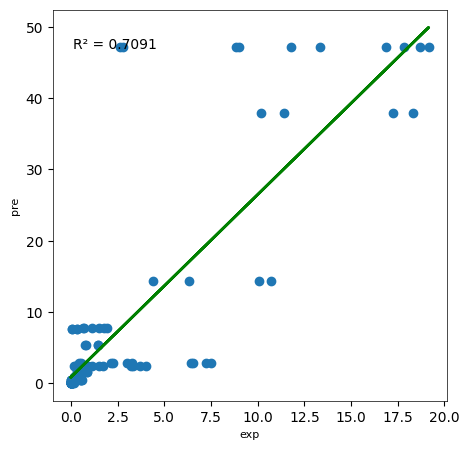

拟合结果 P1_fit： [7.76408357e-03 7.01563945e-03 7.00893109e-03 7.76408357e-03
 7.01563945e-03 7.00893109e-03 7.56304588e+00 4.47647829e-01
 3.83871940e-01 7.56304588e+00 4.47647829e-01 3.83871940e-01
 7.64911092e+00 4.52667235e-01 3.88164928e-01 7.64911092e+00
 4.52667235e-01 3.88164928e-01 7.65994377e+00 4.53299019e-01
 3.88705278e-01 7.65994377e+00 4.53299019e-01 3.88705278e-01
 7.66862205e+00 4.53805145e-01 3.89138157e-01 7.66862205e+00
 4.53805145e-01 3.89138157e-01 7.66970759e+00 4.53868455e-01
 3.89192304e-01 7.66970759e+00 4.53868455e-01 3.89192304e-01
 1.47805207e-01 1.51829890e-02 1.39942853e-02 1.47805207e-01
 1.51829890e-02 1.39942853e-02 4.72054917e+01 2.75963806e+00
 2.36126627e+00 4.72054917e+01 2.75963806e+00 2.36126627e+00
 4.72454587e+01 2.76196898e+00 2.36325986e+00 4.72454587e+01
 2.76196898e+00 2.36325986e+00 4.72504492e+01 2.76226003e+00
 2.36350878e+00 4.72504492e+01 2.76226003e+00 2.36350878e+00
 4.72544407e+01 2.76249281e+00 2.36370788e+00 4.72544407e+01
 2.76249281

C:\Users\Chestnut\AppData\Local\Temp\ipykernel_70412\389172745.py:99: RuntimeWarning: divide by zero encountered in log10
  'log10_exp': np.log10(P1),


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# 读取数据
df = pd.read_csv("E:\\Desktop\\hybir\\414.csv")

# 提取数据列
L1 = df['LBD1'].dropna().values
L2 = df['LBD2'].dropna().values
P1 = df['RPU'].dropna().values
I1 = df['inducer1'].dropna().values
I2 = df['inducer2'].dropna().values



k11 = 4.67083E-05


k21 = 5.31018734

k31 = 1.086833596

kx1=4.230793476

kx2= 4870.637695
kd1 = 1.13083303


k12 = 0.000171923
k22 = 0.256016091
k32 = 225.0817618
kd2 = 40.97704697

Imax1 = 35.84931505
Imax2 = 1.7

I01 = 0.006969286

# 定义模型函数
def func(L1, L2, I1, I2, k11, k21, k31, kx1, kx2, kd1, k12, k22, k32, kd2, Imax1, Imax2, I01):
    x1 = np.sqrt((k21*I1 + kx1 + kx2*k21*I1 + 1)**2 + 8 * L1 * (k21**2 * k31 * I1**2 + k11 + k11*kx1**2 + k31 * k21**2 * kx2**2 * I1**2))
    x2 = np.sqrt((k22 * I2 + 1)**2 + 8 * L2 * (k22**2 * k32 * I2**2 + k12))
    F1 = np.log(L1 / 2) + np.log((x1 - (k21*I1 + kx1 + kx2*k21*I1 + 1)) / (x1 + (k21*I1 + kx1 + kx2*k21*I1 + 1))) + np.log(kd1)
    F2 = np.log(L2 / 2) + np.log((x2 - (k22 * I2 + 1)) / (x2 + (k22 * I2 + 1))) + np.log(kd2)
    x3 = np.sqrt((kx1 + 1)**2 + 8 * L1 * (k11 + k11*kx1**2))
    x4 = np.sqrt(1 + 8 * L2 * k12)
    F3 = np.log(L1 / 2) + np.log((x3 - (kx1 + 1)) / (x3 + (kx1 + 1))) + np.log(kd1)
    F4 = np.log(L2 / 2) + np.log((x4 - 1) / (x4 + 1)) + np.log(kd2)
    P1 = (Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F2))) + I01  # ++
    return P1

# 拟合预测
P1_fit = func(L1, L2, I1, I2, k11, k21, k31, kx1, kx2, kd1, k12, k22, k32, kd2, Imax1, Imax2, I01)


  # 可以换成其他对应 DBD 的 I0
# I02 = 0.011797972  # 暂时没用到
'''
# 模型函数
def func(L1, L2, I1, I2, k11, k21, k31, kd1, k12, k22, k32, kd2, Imax2, I01):
    x1 = np.sqrt((k21 * I1 + 1)**2 + 8 * L1 * (k21**2 * k31 * I1**2 + k11))
    x2 = np.sqrt((k22 * I2 + 1)**2 + 8 * L2 * (k22**2 * k32 * I2**2 + k12))
    F1 = np.log(L1 / 2) + np.log((x1 - (k21 * I1 + 1)) / (x1 + (k21 * I1 + 1))) + np.log(kd1)
    F2 = np.log(L2 / 2) + np.log((x2 - (k22 * I2 + 1)) / (x2 + (k22 * I2 + 1))) + np.log(kd2)
    P1 = (Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F2))) + I01
    return P1

# 计算预测值
P1_fit = func(L1, L2, I1, I2, k11, k21, k31, kd1, k12, k22, k32, kd2, Imax2, I01)
'''

# 绘图
fig, ax = plt.subplots(figsize=(5.08, 5.08))
slope, intercept, r_value, p_value, std_err = linregress(P1, P1_fit)
r_squared = r_value**2

plt.scatter(P1, P1_fit)
plt.xlabel('exp', fontsize=8)
plt.ylabel('pre', fontsize=8)
plt.plot(P1, slope * P1 + intercept, c='g', linewidth=2)
plt.annotate('R² = {:.4f}'.format(r_squared), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10)

# 美化边框
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.show()

# 输出结果
print('拟合结果 P1_fit：', P1_fit)
print('相关系数 r = %.4f' % r_value)

# 保存为 CSV
output_df = pd.DataFrame({
    'exp': P1,
    'pre': P1_fit,
    'log10_exp': np.log10(P1),
    'log10_pre': np.log10(P1_fit)
})

output_path = "E:\\Desktop\\hybir\\414_pre.csv"
output_df.to_csv(output_path, index=False)
print(f"结果已保存到：{output_path}")


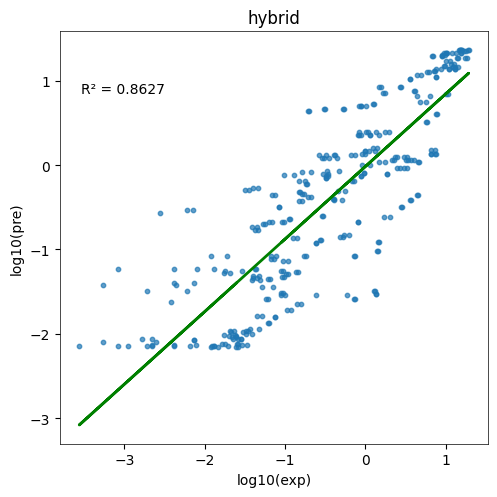

Pearson R（log-log 空间）: 0.8521
Pearson R²（log-log 空间）: 0.7260
原始空间 R²: 0.4665
回归校正后 R²: 0.8627


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.metrics import r2_score

# 三个文件路径
file_paths = [
    "E:\\Desktop\\hybir\\419_pre.csv",
    "E:\\Desktop\\hybir\\417_pre.csv",
    "E:\\Desktop\\hybir\\414_pre.csv"
]

# 合并数据
all_exp, all_pre = [], []

for path in file_paths:
    df = pd.read_csv(path)
    all_exp.extend(df['exp'].values)
    all_pre.extend(df['pre'].values)

# 转为 numpy 数组
exp = np.array(all_exp)
pre = np.array(all_pre)

# 去除 <=0 的值以避免 log 错误
valid = (exp > 0) & (pre > 0)
exp = exp[valid]
pre = pre[valid]

# log10 转换
log_exp = np.log10(exp)
log_pre = np.log10(pre)

# 回归拟合
slope, intercept, r_value, p_value, std_err = linregress(log_exp, log_pre)
r_squared = r_value**2

# 原始空间 R²
r2_raw = r2_score(exp, pre)

# ==== 校正预测值 ====
# 把 log_pre 校正到拟合线（即 log_exp 对应的拟合值）
log_pre_corrected = slope * log_exp + intercept

# 反变换回原始尺度
pre_corrected = 10 ** log_pre_corrected

# 校正后的 R²（更体现拟合线效果）
r2_corrected = r2_score(exp, pre_corrected)

# 可视化（log-log 空间）
fig, ax = plt.subplots(figsize=(5.08, 5.08))
ax.scatter(log_exp, log_pre, s=10, alpha=0.7)
ax.plot(log_exp, log_pre_corrected, color='green', linewidth=2)

ax.set_xlabel("log10(exp)", fontsize=10)
ax.set_ylabel("log10(pre)", fontsize=10)
ax.set_title('hybrid', fontsize=12)

# 标注
#ax.annotate(f"Pearson R² = {r_squared:.4f}", xy=(0.05, 0.92), xycoords='axes fraction', fontsize=8)
#ax.annotate(f"Raw R² = {r2_raw:.4f}", xy=(0.05, 0.85), xycoords='axes fraction', fontsize=8)
ax.annotate(f"R² = {r2_corrected:.4f}", xy=(0.05, 0.85), xycoords='axes fraction', fontsize=10)

# 美化边框
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.savefig("E:\\Desktop\\hybir\\hybrid_R².svg")
plt.show()

# 控制台输出
print(f"Pearson R（log-log 空间）: {r_value:.4f}")
print(f"Pearson R²（log-log 空间）: {r_squared:.4f}")
print(f"原始空间 R²: {r2_raw:.4f}")
print(f"回归校正后 R²: {r2_corrected:.4f}")


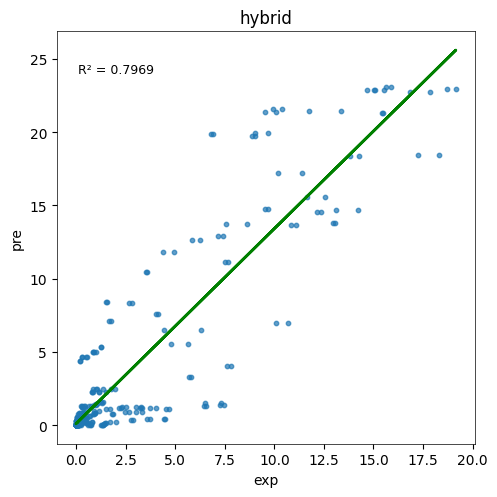

Pearson R: 0.9117 -> 趋势线性相关性
R²（原始）: 0.4883 -> 模型预测还原能力
R²（回归校正后）: 0.7969 -> 拟合误差去除后更接近理想预测情况


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.metrics import r2_score

# 三个文件路径
file_paths = [
    "E:\\Desktop\\hybir\\419_pre.csv",
    "E:\\Desktop\\hybir\\417_pre.csv",
    "E:\\Desktop\\hybir\\414_pre.csv"
]

# 合并所有 exp 和 pre
all_exp, all_pre = [], []

for path in file_paths:
    df = pd.read_csv(path)
    all_exp.extend(df['exp'].values)
    all_pre.extend(df['pre'].values)

# 转为 numpy 数组
exp = np.array(all_exp)
pre = np.array(all_pre)

# ===== 原始线性拟合 =====
slope, intercept, r_value, p_value, std_err = linregress(exp, pre)
r_squared = r_value**2
r2_total = r2_score(exp, pre)

# ===== 做预测值校正（回归变换） =====
pre_corrected = (pre - intercept) / slope  # 或者 pre_fixed = slope * pre + intercept（但这只是拟合线）
r2_corrected = r2_score(exp, pre_corrected)

# ===== 可视化 =====
fig, ax = plt.subplots(figsize=(5.08, 5.08))
plt.scatter(exp, pre, s=10, alpha=0.7)
plt.plot(exp, slope * exp + intercept, color='green', linewidth=2)
plt.title("hybrid", fontsize=12)
plt.xlabel("exp", fontsize=10)
plt.ylabel("pre", fontsize=10)

plt.annotate(f"R² = {r2_corrected:.4f}",
             xy=(0.05, 0.90), xycoords='axes fraction', fontsize=9)

# 边框美化
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()

# ===== 控制台输出 =====
print(f"Pearson R: {r_value:.4f} -> 趋势线性相关性")
print(f"R²（原始）: {r2_total:.4f} -> 模型预测还原能力")
print(f"R²（回归校正后）: {r2_corrected:.4f} -> 拟合误差去除后更接近理想预测情况")


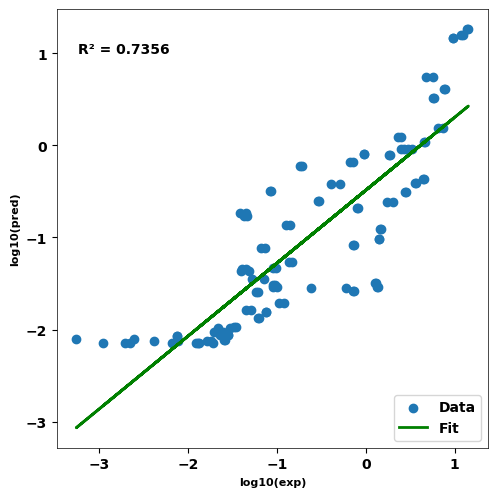

Predicted P1_fit:
 [9.16410457e-03 9.16410457e-03 9.44053181e-03 9.44053181e-03
 1.62654817e-02 1.62654817e-02 3.58206859e-02 3.58206859e-02
 3.82542652e-01 3.82542652e-01 8.11234647e-01 8.11234647e-01
 7.09729019e-03 7.09729019e-03 7.11341172e-03 7.11341172e-03
 7.51145017e-03 7.51145017e-03 8.65193079e-03 8.65193079e-03
 2.88731301e-02 2.88731301e-02 5.38749100e-02 5.38749100e-02
 7.07876516e-03 7.07876516e-03 7.09255356e-03 7.09255356e-03
 7.43298707e-03 7.43298707e-03 8.40841503e-03 8.40841503e-03
 2.57031615e-02 2.57031615e-02 4.70866333e-02 4.70866333e-02
 3.89257118e-01 3.89257118e-01 4.36310479e-01 4.36310479e-01
 1.52692035e+00 1.52692035e+00 4.04858871e+00 4.04858871e+00
 1.55888314e+01 1.55888314e+01 1.83465407e+01 1.83465407e+01
 2.92647250e-02 2.92647250e-02 3.20089278e-02 3.20089278e-02
 9.56144729e-02 9.56144729e-02 2.42680893e-01 2.42680893e-01
 9.15720301e-01 9.15720301e-01 1.07655288e+00 1.07655288e+00
 2.60380840e-02 2.60380840e-02 2.83851402e-02 2.83851402e-02
 8.27

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# 读取数据
df = pd.read_csv("E:\\Desktop\\hybir\\419.csv")

# 提取数据列（确保长度一致）
L1 = df['LBD1'].values
L2 = df['LBD2'].values
P1 = df['RPU'].values
I1 = df['inducer1'].values
I2 = df['inducer2'].values

# 参数
k11 = 0.000268715
k21 = 0.007083518
k31 = 0.760771692
kd1 = 0.745553315

k12 = 0.000171923
k22 = 0.256016091
k32 = 225.0817618
kd2 = 40.97704697

Imax1 = 35.84931505
Imax2 = 0.85546578

I01 = 0.006969286  # 可以换成其他对应 DBD 的 I0
# I02 = 0.011797972  # 暂时没用到

# 模型函数
def func(L1, L2, I1, I2, k11, k21, k31, kd1, k12, k22, k32, kd2, Imax2, I01):
    x1 = np.sqrt((k21 * I1 + 1)**2 + 8 * L1 * (k21**2 * k31 * I1**2 + k11))
    x2 = np.sqrt((k22 * I2 + 1)**2 + 8 * L2 * (k22**2 * k32 * I2**2 + k12))
    F1 = np.log(L1 / 2) + np.log((x1 - (k21 * I1 + 1)) / (x1 + (k21 * I1 + 1))) + np.log(kd1)
    F2 = np.log(L2 / 2) + np.log((x2 - (k22 * I2 + 1)) / (x2 + (k22 * I2 + 1))) + np.log(kd2)
    P1 = (Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F2))) + I01
    return P1

# 计算预测值
P1_fit = func(L1, L2, I1, I2, k11, k21, k31, kd1, k12, k22, k32, kd2, Imax2, I01)

# 只保留正值用于 log10
mask = (P1 > 0) & (P1_fit > 0)
P1_valid = P1[mask]
P1_fit_valid = P1_fit[mask]
P1_log = np.log10(P1_valid)
P1_fit_log = np.log10(P1_fit_valid)

# 计算拟合曲线和 R²
slope, intercept, r_value, p_value, std_err = linregress(P1_log, P1_fit_log)
r_squared = r_value**2

# 画图
fig, ax = plt.subplots(figsize=(5.08, 5.08))
plt.scatter(P1_log, P1_fit_log, label='Data')
plt.plot(P1_log, slope * P1_log + intercept, c='g', linewidth=2, label='Fit')
plt.xlabel('log10(exp)', fontsize=8)
plt.ylabel('log10(pred)', fontsize=8)
plt.title('', fontsize=10)
plt.annotate('R² = {:.4f}'.format(r_squared), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 打印预测值
print("Predicted P1_fit:\n", P1_fit)

# 导出为 CSV 文件
output_df = df.copy()
output_df['P1_fit'] = P1_fit
output_df.to_csv("E:\\Desktop\\hybir\\419_with_predictions.csv", index=False)

# 输出相关性
print('Correlation (R): %.4f' % r_value)
print('R²: %.4f' % r_squared)


极值计算

In [33]:
import numpy as np
from scipy.optimize import minimize

def promoter(params):
    m1, m2 = params
    L1 = m1
    L2 = m2
    k11 = 4.67083E-05
    k21 = 5.31018734
    k31 = 0.650004327
    kx1 = 1.086833596
    kx2 = 4.230793476
    kd1 = 1.13083303
    k12 = 0.000171923
    k22 = 0.256016091
    k32 = 225.0817618
    kd2 = 40.97704697

    Imax1 = 35.84931505
    Imax2 = 0.85546578
    I1=I2=1

    I01 = 0.006969286
    I02 = 0.011797972


    x1 = np.sqrt((k21*I1+kx1+kx2*k21*I1+1)*(k21*I1+kx1+kx2*k21*I1+1)+ 8 * L1 * (k21*k21*k31*I1*I1 + k11+k11*kx1*kx1+k31*k21*k21*kx2*kx2*I1*I1))
    x2 = np.sqrt((k22 * I2 + 1) * (k22 * I2 + 1) + 8 * L2 * (k22 * k22 * k32 * I2 * I2 + k12))
    F1 = np.log(L1 / 2) + np.log((x1 - (k21*I1+kx1+kx2*k21*I1+1)) / (x1 + (k21*I1+kx1+kx2*k21*I1+1))) + np.log(kd1)
    F2 = np.log(L2 / 2) + np.log((x2 - (k22 * I2 + 1)) / (x2 + (k22 * I2 + 1))) + np.log(kd2)
    x3 = np.sqrt((kx1+1)*(kx1+1)+ 8 * L1 * ( k11+k11*kx1*kx1))
    x4 = np.sqrt(( 1) * ( 1) + 8 * L2 * (k12))
    F3 = np.log(L1 / 2) + np.log((x3 - (kx1+1)) / (x3 + (kx1+1))) + np.log(kd1)
    F4 = np.log(L2 / 2) + np.log((x4 - (1)) / (x4 + ( 1))) + np.log(kd2)
    P1 =  (Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F2))) + I01 #++
    P2 =  (Imax1 / (1 + np.exp(-F3))) * (Imax2 / (1 + np.exp(F4))) + I01 #--
    P3 =  (Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F4))) + I01 #+-
    P4 =  (Imax1 / (1 + np.exp(-F3))) * (Imax2 / (1 + np.exp(F2))) + I01 #-+
    fold = P3/P1+P3/P2+P3/P4
    strength = 3*P3-(P4+P1+P2)
    a1=(1 / (1 + np.exp(-F1)))
    a2=(1 / (1 + np.exp(F2)))

    return -(np.log10(fold)+np.log10(strength))

# 初始猜测值
initial_guess = [1, 1]

# 全局搜索最大值
result = minimize(promoter, initial_guess, method='nelder-mead', options={'xatol': 1e-8, 'disp': True})

# 输出找到的最大值
if result.success:
    print("Maximum value of promoter function:", -result.fun)
    print("Parameter corresponding to the maximum value:", result.x)
else:
    print("Failed to find the maximum value.")

Optimization terminated successfully.
         Current function value: -5.322045
         Iterations: 71
         Function evaluations: 154
Maximum value of promoter function: 5.3220445417817634
Parameter corresponding to the maximum value: [9.571567   2.71052049]


In [139]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd

def promoter(m1, m2):
    L1 = m1
    L2 = m2
    k11 = 0.000268715

    k21 = 0.007083518
    k31 = 0.760771692

    kd1 = 0.745553315

    k12 = 0.000171923
    k22 = 0.256016091
    k32 = 225.0817618
    kd2 = 40.97704697
    Imax1 = 35.84931505
    Imax2 = 0.85546578
    I1=100
    I2=10

    I01 = 0.006969286
    I02 = 0.011797972


    x1 = np.sqrt((k21*I1+1)*(k21*I1+1)+ 8 * L1 * (k21*k21*k31*I1*I1 + k11))
    x2 = np.sqrt((k22 * I2 + 1) * (k22 * I2 + 1) + 8 * L2 * (k22 * k22 * k32 * I2 * I2 + k12))
    F1 = np.log(L1 / 2) + np.log((x1 - (k21*I1+1)) / (x1 + (k21*I1+1))) + np.log(kd1)
    F2 = np.log(L2 / 2) + np.log((x2 - (k22 * I2 + 1)) / (x2 + (k22 * I2 + 1))) + np.log(kd2)
    x3 = np.sqrt((1)*(1)+ 8 * L1 * ( k11))
    x4 = np.sqrt(( 1) * ( 1) + 8 * L2 * (k12))
    F3 = np.log(L1 / 2) + np.log((x3 - (1)) / (x3 + (1))) + np.log(kd1)
    F4 = np.log(L2 / 2) + np.log((x4 - (1)) / (x4 + ( 1))) + np.log(kd2)
    P1 =  (Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F2))) + I01 #++
    P2 =  (Imax1 / (1 + np.exp(-F3))) * (Imax2 / (1 + np.exp(F4))) + I01 #--
    P3 =  (Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F4))) + I01 #+-
    P4 =  (Imax1 / (1 + np.exp(-F3))) * (Imax2 / (1 + np.exp(F2))) + I01 #-+
    fold = P3/P1+P3/P2+P3/P4
    strength = 3*P3-(P4+P1+P2)
    a1=(1 / (1 + np.exp(-F1)))
    a2=(1 / (1 + np.exp(F2)))

    #print(a1,a2)

    return P1
print(promoter(0.6, 1))

0.04708663330845538


In [120]:
import numpy as np
from scipy.optimize import minimize

def promoter(m1,m2):
    L1 = m1
    L2 = m2
    k11 = 4.67083E-05
    k21 = 5.31018734
    k31 = 0.650004327
    kx1 = 1.086833596
    kx2 = 4.230793476
    kd1 = 1.13083303
    k12 = 0.000171923
    k22 = 0.256016091
    k32 = 225.0817618
    kd2 = 40.97704697

    Imax1 = 35.84931505
    Imax2 = 0.85546578
    I1=0
    I2=10
    I01 = 0.006969286
    I02 = 0.011797972


    x1 = np.sqrt((k21*I1+kx1+kx2*k21*I1+1)*(k21*I1+kx1+kx2*k21*I1+1)+ 8 * L1 * (k21*k21*k31*I1*I1 + k11+k11*kx1*kx1+k31*k21*k21*kx2*kx2*I1*I1))
    x2 = np.sqrt((k22 * I2 + 1) * (k22 * I2 + 1) + 8 * L2 * (k22 * k22 * k32 * I2 * I2 + k12))
    F1 = np.log(L1 / 2) + np.log((x1 - (k21*I1+kx1+kx2*k21*I1+1)) / (x1 + (k21*I1+kx1+kx2*k21*I1+1))) + np.log(kd1)
    F2 = np.log(L2 / 2) + np.log((x2 - (k22 * I2 + 1)) / (x2 + (k22 * I2 + 1))) + np.log(kd2)
    x3 = np.sqrt((kx1+1)*(kx1+1)+ 8 * L1 * ( k11+k11*kx1*kx1))
    x4 = np.sqrt(( 1) * ( 1) + 8 * L2 * (k12))
    F3 = np.log(L1 / 2) + np.log((x3 - (kx1+1)) / (x3 + (kx1+1))) + np.log(kd1)
    F4 = np.log(L2 / 2) + np.log((x4 - (1)) / (x4 + ( 1))) + np.log(kd2)
    P1 =  (Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F2))) + I01 #++
    P2 =  (Imax1 / (1 + np.exp(-F3))) * (Imax2 / (1 + np.exp(F4))) + I01 #--
    P3 =  (Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F4))) + I01 #+-
    P4 =  (Imax1 / (1 + np.exp(-F3))) * (Imax2 / (1 + np.exp(F2))) + I01 #-+
    fold = P3/P1+P3/P2+P3/P4
    strength = 3*P3-(P4+P1+P2)
    a1=(1 / (1 + np.exp(-F1)))
    a2=(1 / (1 + np.exp(F2)))

    return P1
print(promoter(6,0.8))

0.008765862938881


<Figure size 700x600 with 0 Axes>

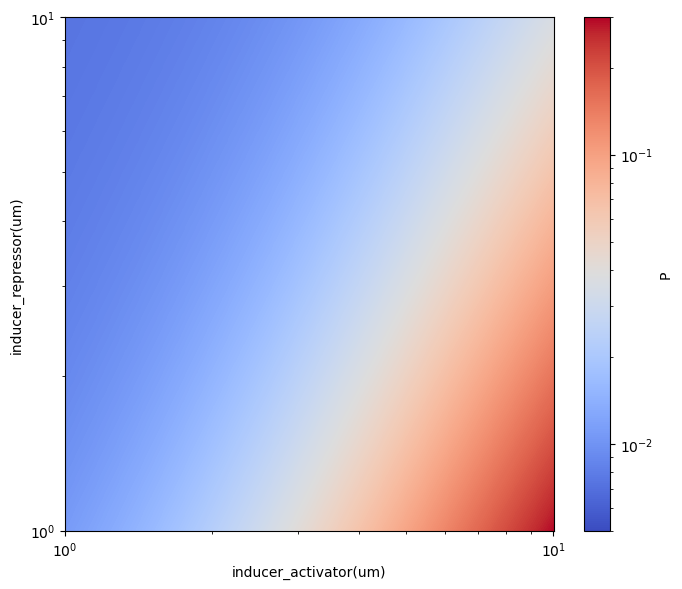

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text
from matplotlib.colors import LogNorm
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap

def promoter(m1, m2):
    L1= m1
    L2 =m2
    #I1 = m1
    #I2 = m2
    k11 = 0.000268715
    k21 = 0.007083518
    k31 = 0.760771692
    #kx1 = 1.086833596
    #kx2 = 4.230793476
    kd1 = 0.745553315
    k12 = 0.000171923
    k22 = 0.256016091
    k32 = 225.0817618
    kd2 = 40.97704697
    Imax1 = 35.84931505
    Imax2 = 0.85546578

    I01 = 0.006969286
    I02 = 0.011797972
    I1 = 10
    I2 = 10
    #L1= 1.5
    #L2= 1.5
 
    x1 = np.sqrt((k21*I1+1)*(k21*I1+1)+ 8 * L1 * (k21*k21*k31*I1*I1 + k11))

    F1 = np.log(L1 / 2) + np.log((x1 - (k21*I1+1)) / (x1 + (k21*I1+1))) + np.log(kd1)

    #x1 = np.sqrt((k21*I1+kx1+kx2*k21*I1+1)*(k21*I1+kx1+kx2*k21*I1+1)+ 8 * L1 * (k21*k21*k31*I1*I1 + k11+k11*kx1*kx1+k31*k21*k21*kx2*kx2*I1*I1))
    x2 = np.sqrt((k22 * I2 + 1) * (k22 * I2 + 1) + 8 * L2 * (k22 * k22 * k32 * I2 * I2 + k12))
    #F1 = np.log(L1 / 2) + np.log((x1 - (k21*I1+kx1+kx2*k21*I1+1)) / (x1 + (k21*I1+kx1+kx2*k21*I1+1))) + np.log(kd1)
    F2 = np.log(L2 / 2) + np.log((x2 - (k22 * I2 + 1)) / (x2 + (k22 * I2 + 1))) + np.log(kd2)
    P =  (Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F2))) + I01

    a1=(1 / (1 + np.exp(-F1)))
    a2=(1 / (1 + np.exp(F2)))

    #print(a1,a2)

    return P


m1 = np.logspace(0, 1,1000)
m2 = np.logspace(0, 1, 1000)
M1, M2 = np.meshgrid(m1, m2)
plt.figure(figsize=(7,6))
fig, ax = plt.subplots(figsize=(7,6))

colors = [(0.0, '#C9E3AC'), (0.5, '#90BE6D'), (1.0, '#EA9010')]
cmap = LinearSegmentedColormap.from_list('custom cmap', colors)



cp = ax.pcolormesh(M1, M2, (promoter(M1, M2)), cmap='coolwarm',norm=LogNorm(vmin=0.005, vmax=0.3))
#, norm=LogNorm(vmin=0.005, vmax=0.5)

cbar = fig.colorbar(cp)
cbar.ax.set_ylabel('P')

# 设置横纵坐标轴标签及其缩放
ax.set_xlabel('inducer_activator(um)')
ax.set_ylabel('inducer_repressor(um)')
ax.set_xscale('log')
ax.set_yscale('log')


#plt.title("pre")
plt.tight_layout()
'''
df = pd.read_csv("E:\Desktop\hybir\\417_1.csv")
a = df["inducer1"]
b = df["inducer2"]
c = df["RPU"]
#plt.scatter(a,c,  cmap='coolwarm',s=20)
'''
plt.show()
#plt.savefig('E:\Desktop\\LBD_DBD\\LasR.svg')

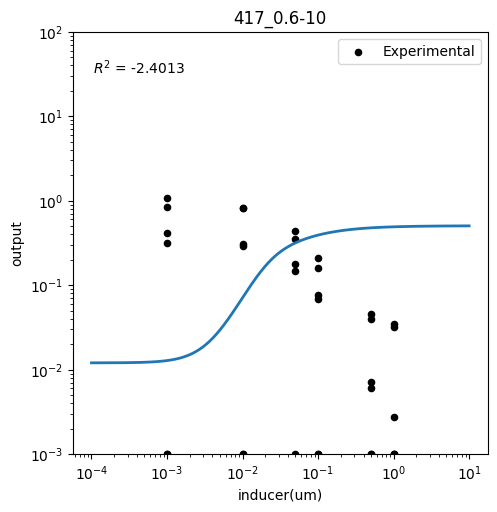

In [151]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text
from matplotlib.colors import LogNorm
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap

def promoter(m1, m2):
    #L1= m1
    #L2 =m2
    I1 = m1
    I2 = m2
    k11 = 4.67083E-05

    k21 = 5.31018734


    k31 = 0.650004327

    kx1 = 1.086833596

    kx2 = 4.230793476

    kd1 = 1.13083303

    k12 = 0.000171923
    k22 = 0.256016091
    k32 = 225.0817618
    kd2 = 1.445352554

    Imax1 = 35.84931505
    Imax2 = 0.687512595

    I01 = 0.006969286


    I02 = 0.011797972

    #I1 = 10
    #I2 = 10
    L1= 0.6
    L2= 10
 
    #x1 = np.sqrt((k21*I1+1)*(k21*I1+1)+ 8 * L1 * (k21*k21*k31*I1*I1 + k11))

    #F1 = np.log(L1 / 2) + np.log((x1 - (k21*I1+1)) / (x1 + (k21*I1+1))) + np.log(kd1)

    x1 = np.sqrt((k21*I1+kx1+kx2*k21*I1+1)*(k21*I1+kx1+kx2*k21*I1+1)+ 8 * L1 * (k21*k21*k31*I1*I1 + k11+k11*kx1*kx1+k31*k21*k21*kx2*kx2*I1*I1))
    x2 = np.sqrt((k22 * I2 + 1) * (k22 * I2 + 1) + 8 * L2 * (k22 * k22 * k32 * I2 * I2 + k12))
    F1 = np.log(L1 / 2) + np.log((x1 - (k21*I1+kx1+kx2*k21*I1+1)) / (x1 + (k21*I1+kx1+kx2*k21*I1+1))) + np.log(kd1)
    F2 = np.log(L2 / 2) + np.log((x2 - (k22 * I2 + 1)) / (x2 + (k22 * I2 + 1))) + np.log(kd2)
    P =  (Imax1 / (1 + np.exp(-F1))) *  (Imax2 * (1 - ((1 - (1 / (1 + np.exp(F2))))**2)) )  + I02

    a1=(1 / (1 + np.exp(-F1)))
    a2=(1 / (1 + np.exp(F2)))

    #print(a1,a2)

    return P

m1 = np.logspace(-4,1 ,1000)
m2 = np.logspace(-4, 1, 1000)
M1, M2 = np.meshgrid(m1, m2)
fig, ax = plt.subplots(figsize=(5.08,5.08))

colors = [(0.0, '#C9E3AC'), (0.5, '#90BE6D'), (1.0, '#EA9010')]
cmap = LinearSegmentedColormap.from_list('custom cmap', colors)
ax.plot(m2, promoter(m1, m2), linewidth=2)


#cp = ax.pcolormesh(M1, M2, (promoter(M1, M2)), cmap='coolwarm',norm=LogNorm(vmin=0.005, vmax=0.3))
#, norm=LogNorm(vmin=0.005, vmax=0.5)

#cbar = fig.colorbar(cp)
#cbar.ax.set_ylabel('P')

# 设置横纵坐标轴标签及其缩放
ax.set_xlabel('inducer(um)')
ax.set_ylabel('output')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(10**(-3), 10**2)

#plt.title("pre")
plt.tight_layout()

df = pd.read_csv("E:\Desktop\hybir\\417_3.csv")
plt.title("417_0.6-10")
a = df["inducer1"]
b = df["inducer2"]
c = df["RPU"]
from sklearn.metrics import r2_score
import numpy as np

# 预测值
pre = promoter(a.values, b.values)
exp = c.values

# 原始 R²
r2_raw = r2_score(exp, pre)

# 线性校正
slope, intercept = np.polyfit(pre, exp, 1)
pre_corrected = slope * pre + intercept

# 校正后 R²
r2_corrected = r2_score(exp, pre_corrected)

# 绘图散点
plt.scatter(b, c, c='black', s=20, label='Experimental')

# 添加文字注释到图中
plt.annotate(f"$R^2$ = {r2_raw:.4f}", xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)
#plt.annotate(f"$R^2$ = {r2_corrected:.4f}", xy=(0.05, 0.83), xycoords='axes fraction', fontsize=10)

plt.legend()

plt.savefig('E:\Desktop\hybir\curve\\417_3.svg')
plt.show()


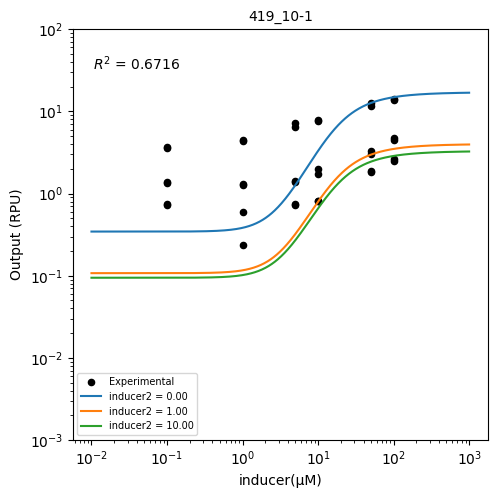

In [233]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import r2_score

# === 模型函数 ===
def promoter(m1, m2):
    I1 = m1
    I2 = m2
    k11 = 0.000268715

    k21 = 0.007083518

    k31 = 0.760771692
    #kx1 = 1.086833596
    #kx2 = 4.230793476
    kd1 = 0.745553315



    k12 = 0.000171923
    k22 = 0.256016091
    k32 = 225.0817618
    kd2 = 40.97704697



    Imax1 = 35.84931505
    Imax2 = 0.687512595
    I01 = 0.015930056



    I02 = 0.035485714



    L1 = 8
    L2 = 0.48
    
    x1 = np.sqrt((k21*I1+1)*(k21*I1+1)+ 8 * L1 * (k21*k21*k31*I1*I1 + k11))

    F1 = np.log(L1 / 2) + np.log((x1 - (k21*I1+1)) / (x1 + (k21*I1+1))) + np.log(kd1)

    #x1 = np.sqrt((k21*I1 + kx1 + kx2*k21*I1 + 1)**2 +
    #           8 * L1 * (k21**2 * k31 * I1**2 + k11 + k11*kx1**2 + k31*k21**2*kx2**2*I1**2))
    x2 = np.sqrt((k22 * I2 + 1)**2 +
                 8 * L2 * (k22**2 * k32 * I2**2 + k12))

    #F1 = np.log(L1 / 2) + np.log((x1 - (k21*I1 + kx1 + kx2*k21*I1 + 1)) / (x1 + (k21*I1 + kx1 + kx2*k21*I1 + 1))) + np.log(kd1)
    F2 = np.log(L2 / 2) + np.log((x2 - (k22 * I2 + 1)) / (x2 + (k22 * I2 + 1))) + np.log(kd2)

    #P =(Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F2))) + I01
    P =   (Imax1 / (1 + np.exp(-F1))) *  (Imax2 * (1 - ((1 - (1 / (1 + np.exp(F2))))**2)) )  + I02
    return P

# === 数据读取 ===
df = pd.read_csv("E:/Desktop/hybir/419_2.csv")
a = df["inducer1"]
b = df["inducer2"]
c = df["RPU"]

# === 散点图：实验点 ===
fig, ax = plt.subplots(figsize=(5.08, 5.08))
ax.scatter(a, c, c='black', s=20, label='Experimental')

# === R²计算 ===
pre = promoter(a.values, b.values)
exp = c.values
r2_raw = r2_score(exp, pre)

# 原始R²标注
plt.annotate(f"$R^2$ = {r2_raw:.4f}", xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)

# === 自动生成多条预测曲线（按照 inducer2 分类） ===
inducer1_range = np.logspace(-2, 3, 1000)
unique_inducer2 = np.unique(b.round(4))  # 去重并保留小数精度避免浮点误差
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_inducer2)))

for i, fixed_inducer2 in enumerate(unique_inducer2):
    curve = promoter(inducer1_range, np.full_like(inducer1_range, fixed_inducer2))
    ax.plot(inducer1_range, curve, linewidth=1.5,
            label=f'inducer2 = {fixed_inducer2:.2f}')

# === 图形设置 ===
ax.set_xlabel('inducer(μM)')
ax.set_ylabel('Output (RPU)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-3, 1e2)
ax.legend(fontsize=7, loc='best')
plt.title("419_10-1", fontsize=10)
plt.tight_layout()
plt.savefig("E:/Desktop/hybir/curve/419_2.svg")
plt.show()


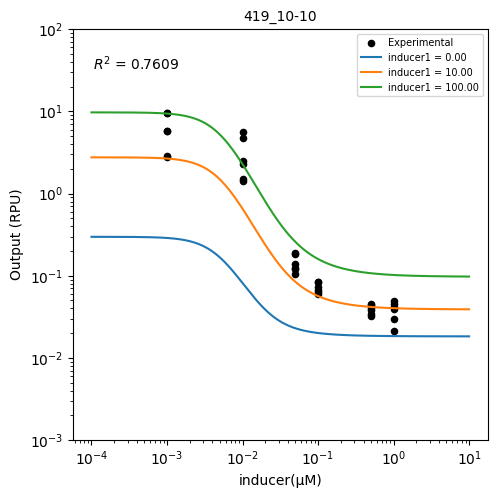

In [207]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import r2_score

# === 模型函数 ===
def promoter(m1, m2):
    I1 = m1
    I2 = m2
    k11 = 0.000268715


    k21 = 0.007083518

    k31 = 0.760771692
    #kx1 = 1.086833596
    #kx2 = 4.230793476
    kd1 = 0.745553315

    k12 = 0.000171923
    k22 = 0.256016091
    k32 = 225.0817618
    kd2 = 40.97704697



    Imax1 = 35.84931505
    Imax2 = 0.687512595
    I01 = 0.015930056

    I02 = 0.035485714


    L1 = 10
    L2 = 10
    x1 = np.sqrt((k21*I1+1)*(k21*I1+1)+ 8 * L1 * (k21*k21*k31*I1*I1 + k11))

    F1 = np.log(L1 / 2) + np.log((x1 - (k21*I1+1)) / (x1 + (k21*I1+1))) + np.log(kd1)


    #x1 = np.sqrt((k21*I1 + kx1 + kx2*k21*I1 + 1)**2 +
    #             8 * L1 * (k21**2 * k31 * I1**2 + k11 + k11*kx1**2 + k31*k21**2*kx2**2*I1**2))
    x2 = np.sqrt((k22 * I2 + 1)**2 +
                 8 * L2 * (k22**2 * k32 * I2**2 + k12))

    #F1 = np.log(L1 / 2) + np.log((x1 - (k21*I1 + kx1 + kx2*k21*I1 + 1)) / (x1 + (k21*I1 + kx1 + kx2*k21*I1 + 1))) + np.log(kd1)
    F2 = np.log(L2 / 2) + np.log((x2 - (k22 * I2 + 1)) / (x2 + (k22 * I2 + 1))) + np.log(kd2)
    P =(Imax1 / (1 + np.exp(-F1))) * (Imax2 / (1 + np.exp(F2))) + I01
    #P =   (Imax1 / (1 + np.exp(-F1))) *  (Imax2 * (1 - ((1 - (1 / (1 + np.exp(F2))))**2)) )  + I01

    return P

# === 数据读取 ===
df = pd.read_csv("E:/Desktop/hybir/419_4.csv")
a = df["inducer1"]
b = df["inducer2"]
c = df["RPU"]

# === 散点图：实验点 ===
fig, ax = plt.subplots(figsize=(5.08, 5.08))
ax.scatter(b, c, c='black', s=20, label='Experimental')

# === R²计算 ===
pre = promoter(a.values, b.values)
exp = c.values
r2_raw = r2_score(exp, pre)

# 原始R²标注
plt.annotate(f"$R^2$ = {r2_raw:.4f}", xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)
# 固定几个 inducer1（activator）值：
unique_inducer1 = np.unique(df["inducer1"].round(4))

# 对每个固定 inducer1，画出不同的 inducer2（横轴）
for i, inducer1_fixed in enumerate(unique_inducer1):
    inducer2_range = np.logspace(-4, 1, 1000)
    curve = promoter(np.full_like(inducer2_range, inducer1_fixed), inducer2_range)
    ax.plot(inducer2_range, curve, label=f'inducer1 = {inducer1_fixed:.2f}')


# === 图形设置 ===
ax.set_xlabel('inducer(μM)')
ax.set_ylabel('Output (RPU)')
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylim(1e-3, 1e2)
ax.legend(fontsize=7, loc='best')
plt.title("419_10-10", fontsize=10)
plt.tight_layout()
plt.savefig("E:/Desktop/hybir/curve/419_4.svg")
plt.show()
